Multi story + Single story IDF wall reader

In [ ]:
'''
This code checks for correct windows and corridors assignment
'''

from geomeppy import IDF
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import re


IDD_PATH = r"C:\Users\Heng_\OneDrive\Desktop\Apps\EnergyPlusV9-1-0\Energy+.idd"
IDF_PATH = r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk863_EM\annual\blk863_EM_ConcreteWall_AC24h\blk863_EM_ConcreteWall_AC24h.idf"

IDF.setiddname(IDD_PATH)
idf = IDF(IDF_PATH)


# ============================================================
# Helpers
# ============================================================

def get_wall_id(name):
    match = re.search(r"Wall\s+(\S+)", name)
    return match.group(1) if match else name


def get_storey(wall):
    text = f"{wall.Name} {wall.Zone_Name}"
    match = re.search(r"Storey\s+(\d+)", text, re.IGNORECASE)
    return int(match.group(1)) if match else None


def get_wall_xy(wall):
    xy = []

    for x, y, z in wall.coords:
        point = (round(x, 6), round(y, 6))

        if point not in xy:
            xy.append(point)

    return (xy[0], xy[1]) if len(xy) >= 2 else None


def get_window_walls(idf):
    return {
        window.Building_Surface_Name
        for window in idf.idfobjects["FENESTRATIONSURFACE:DETAILED"]
        if window.Surface_Type.strip().lower() == "window"
    }


def get_wall_colour(wall, window_walls):
    if wall.Name in window_walls:
        return "blue"

    sun = wall.Sun_Exposure.strip().lower()
    wind = wall.Wind_Exposure.strip().lower()

    if sun == "nosun" and wind == "windexposed":
        return "green"

    if sun == "nosun" and wind == "nowind":
        return "black"

    return "red"


# ============================================================
# Plot one storey
# ============================================================

def plot_storey(idf, storey):

    all_walls = idf.getsurfaces("wall")

    walls = [
        wall
        for wall in all_walls
        if get_storey(wall) == storey
    ]

    wall_lookup = {
        wall.Name: wall
        for wall in all_walls
    }

    window_walls = get_window_walls(idf)

    plotted_pairs = set()

    fig, ax = plt.subplots(figsize=(18, 8))

    for wall in walls:

        endpoints = get_wall_xy(wall)

        if endpoints is None:
            continue

        (x1, y1), (x2, y2) = endpoints

        wall_id = get_wall_id(wall.Name)
        label = wall_id

        # ----------------------------------------------------
        # Shared wall
        # ----------------------------------------------------

        if wall.Outside_Boundary_Condition.strip().lower() == "surface":

            other_name = wall.Outside_Boundary_Condition_Object
            other_wall = wall_lookup.get(other_name)

            if other_wall:

                pair = tuple(
                    sorted([
                        wall.Name,
                        other_wall.Name
                    ])
                )

                if pair in plotted_pairs:
                    continue

                plotted_pairs.add(pair)

                label = (
                    f"{wall_id} / "
                    f"{get_wall_id(other_wall.Name)}"
                )

        # ----------------------------------------------------
        # Draw
        # ----------------------------------------------------

        colour = get_wall_colour(
            wall,
            window_walls
        )

        ax.plot(
            [x1, x2],
            [y1, y2],
            color=colour,
            linewidth=2.5
        )

        ax.text(
            (x1 + x2) / 2,
            (y1 + y2) / 2,
            label,
            fontsize=7,
            color=colour,
            ha="center",
            va="center",
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.75,
                pad=1
            )
        )

    # --------------------------------------------------------
    # Legend
    # --------------------------------------------------------

    legend = [
        Line2D([0], [0], color="blue", lw=3,
               label="Window wall"),

        Line2D([0], [0], color="green", lw=3,
               label="NoSun + WindExposed"),

        Line2D([0], [0], color="black", lw=3,
               label="NoSun + NoWind"),

        Line2D([0], [0], color="red", lw=3,
               label="SunExposed + WindExposed")
    ]

    ax.legend(
        handles=legend,
        loc="best"
    )

    ax.set_aspect("equal")

    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")

    ax.set_title(
        f"IDF Floorplan — Storey {storey}"
    )

    ax.grid(
        True,
        alpha=0.15
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# Plot every storey
# ============================================================

def plot_all_storeys(idf):

    storeys = sorted({
        get_storey(wall)
        for wall in idf.getsurfaces("wall")
        if get_storey(wall) is not None
    })

    print("Storeys found:", storeys)

    for storey in storeys:
        plot_storey(
            idf,
            storey
        )


# ============================================================
# Run
# ============================================================

plot_all_storeys(idf)

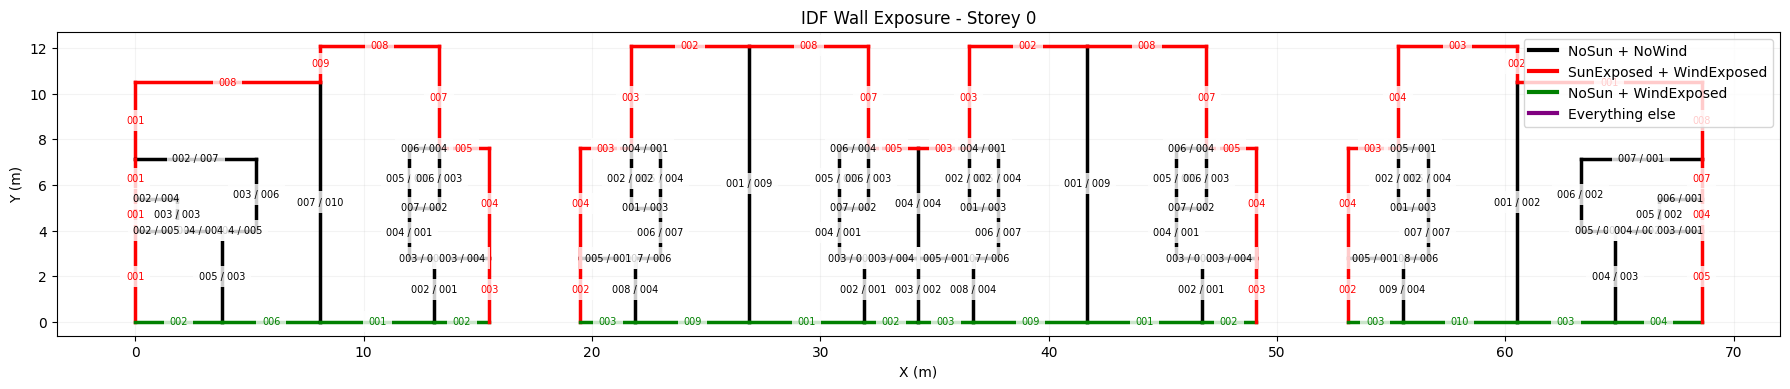

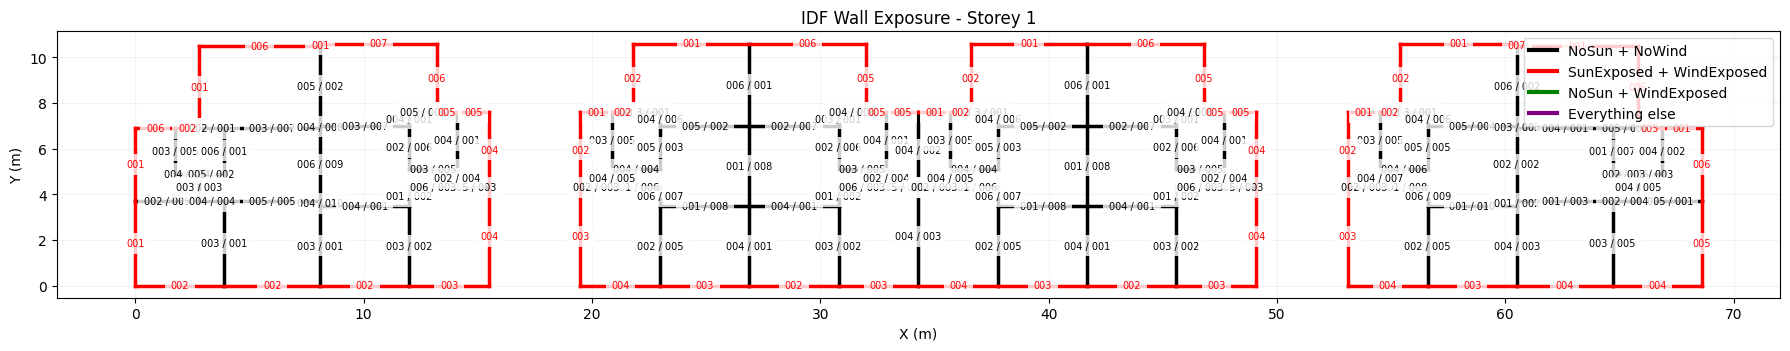

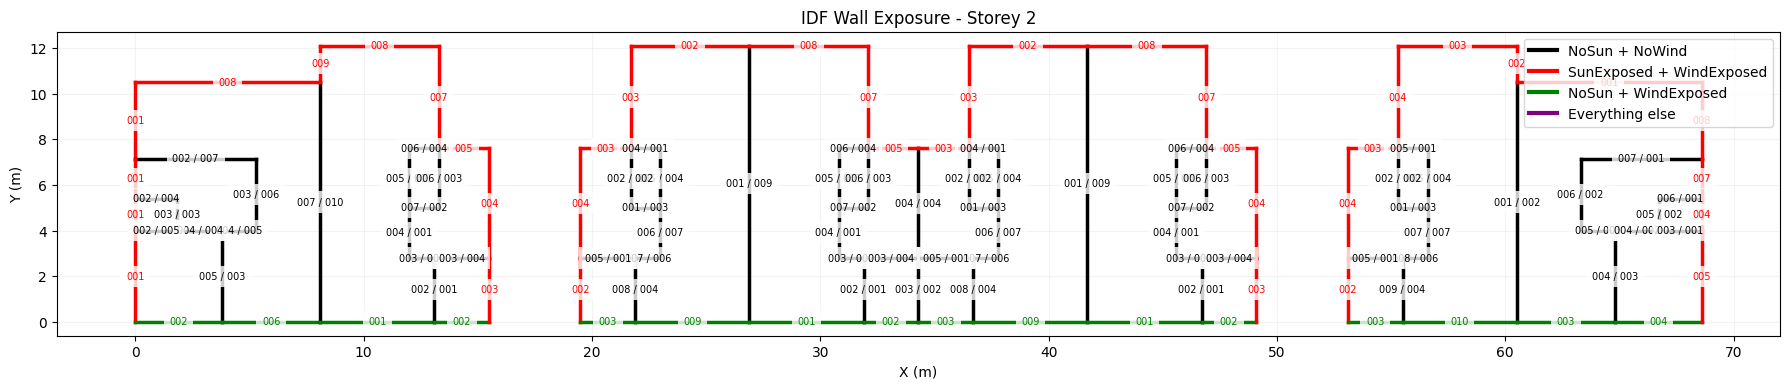

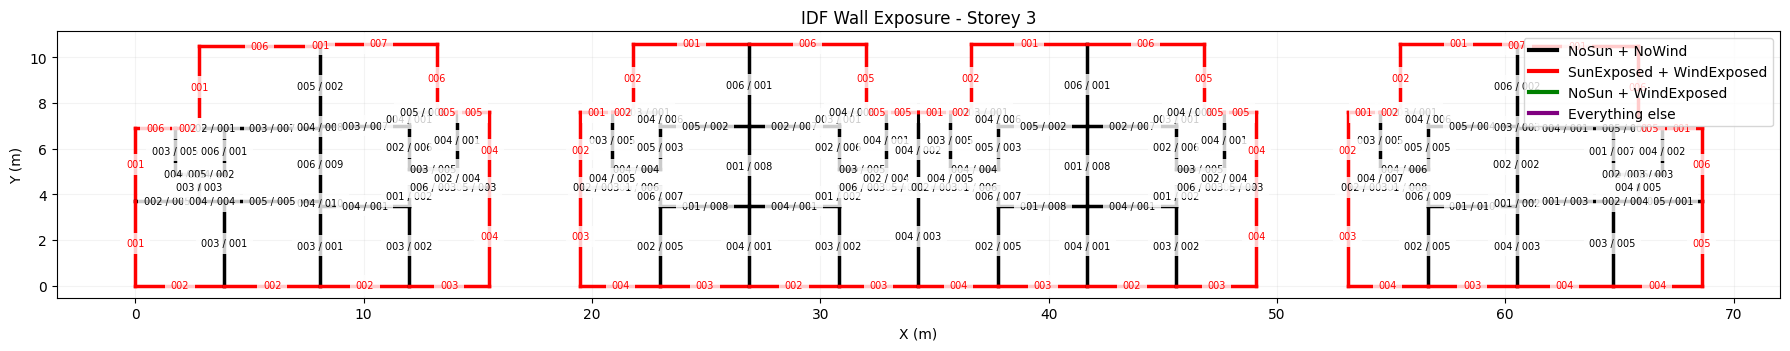

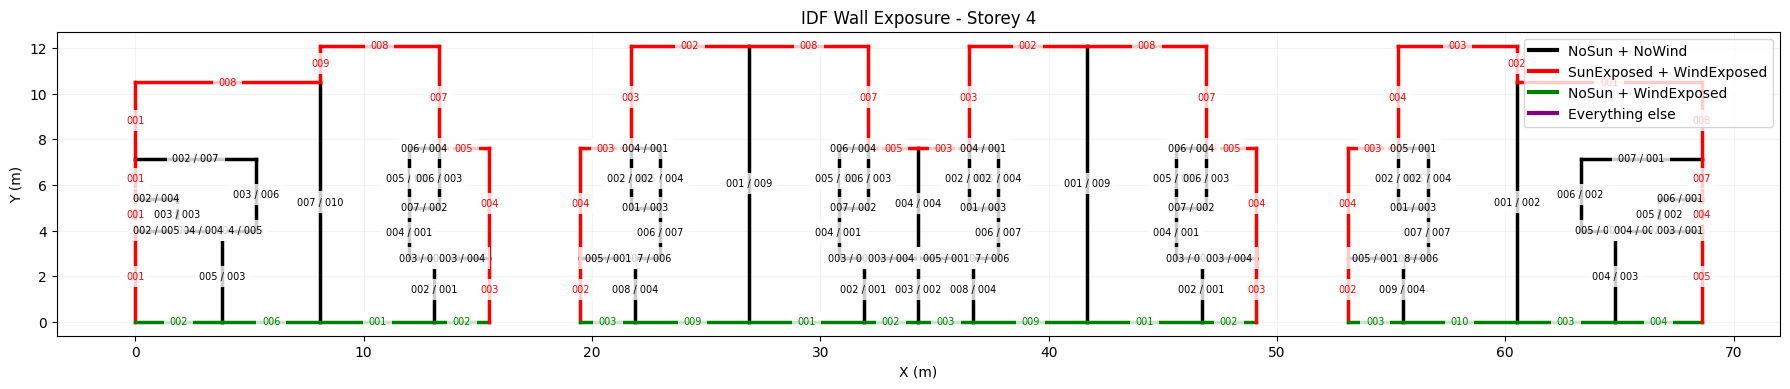

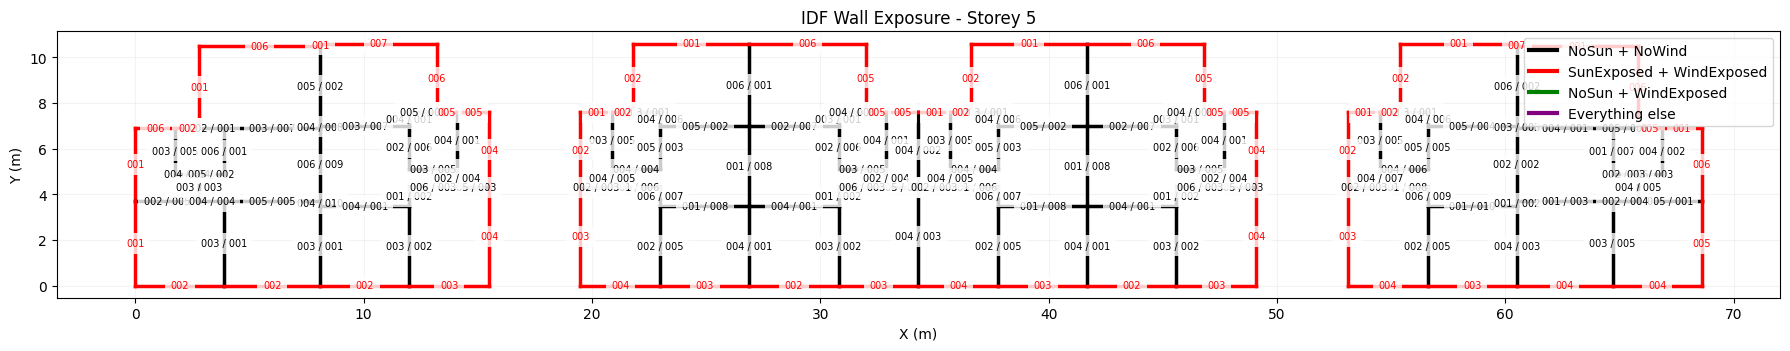

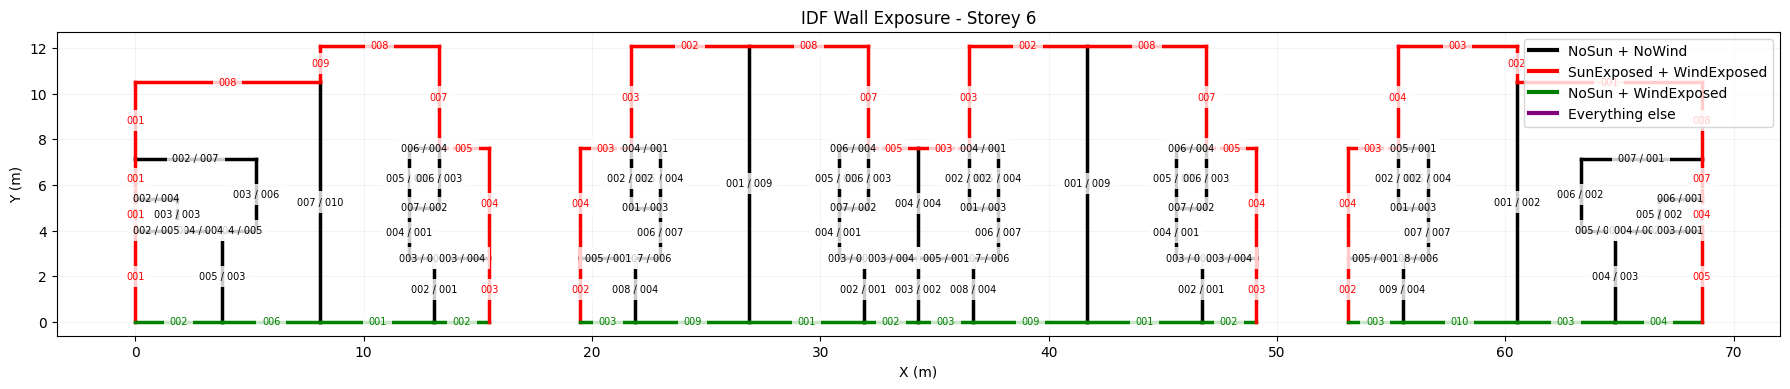

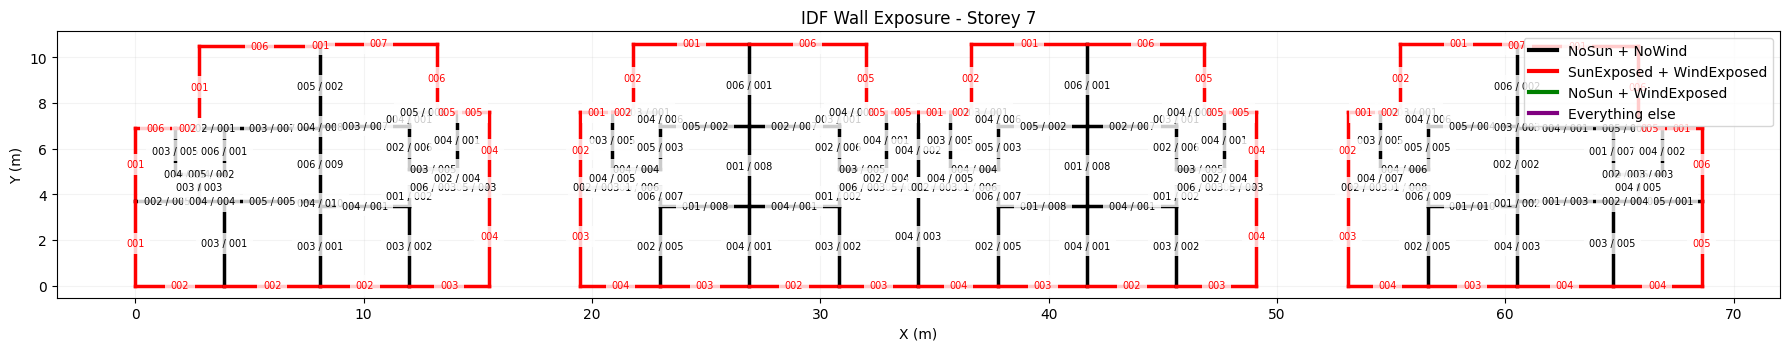

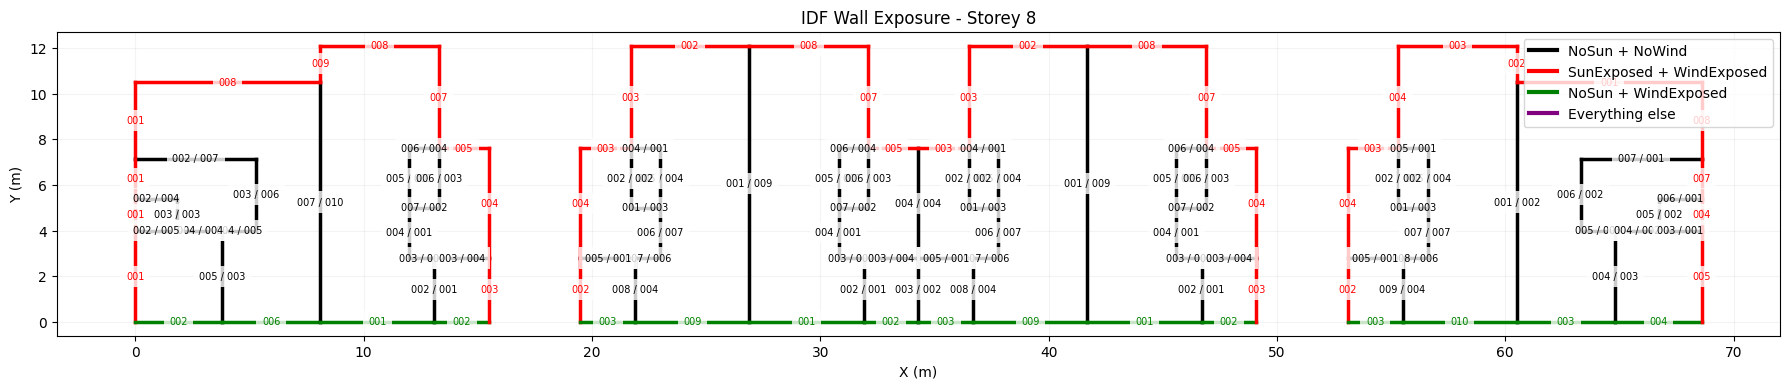

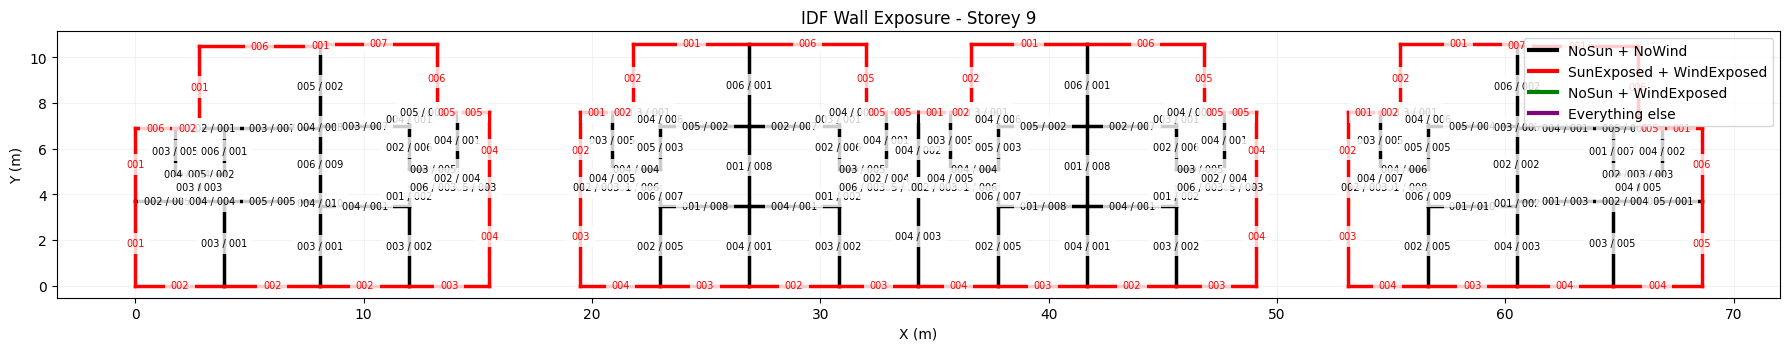

In [2]:
'''
This code checks for correct exposure conditions
Window = SunExposed + WindExposed
Corridor = NoSun + WindExposed
Window + Corridor = NoSun + WindExposed
Interior = NoSun + NoWind
'''

from geomeppy import IDF
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import re


IDD_PATH = r"C:\Users\Heng_\OneDrive\Desktop\Apps\EnergyPlusV9-1-0\Energy+.idd"
IDF_PATH = r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk863_EM\annual\blk863_EM_ConcreteWall_AC24h\blk863_EM_ConcreteWall_AC24h.idf"

IDF.setiddname(IDD_PATH)
idf = IDF(IDF_PATH)


def wall_id(name):
    match = re.search(r"Wall\s+(\S+)", name)
    return match.group(1) if match else name


def storey_number(wall):
    text = f"{wall.Name} {wall.Zone_Name}"
    match = re.search(r"Storey\s+(\d+)", text, re.IGNORECASE)
    return int(match.group(1)) if match else None


def wall_xy(wall):
    xy = list(dict.fromkeys(
        (round(x, 6), round(y, 6))
        for x, y, z in wall.coords
    ))
    return xy[:2] if len(xy) >= 2 else None


def wall_colour(wall):
    condition = (
        wall.Sun_Exposure.strip().lower(),
        wall.Wind_Exposure.strip().lower()
    )

    return {
        ("nosun", "nowind"): "black",
        ("sunexposed", "windexposed"): "red",
        ("nosun", "windexposed"): "green",
    }.get(condition, "purple")


def plot_storey(idf, storey):
    all_walls = idf.getsurfaces("wall")
    walls = [w for w in all_walls if storey_number(w) == storey]
    lookup = {w.Name: w for w in all_walls}
    plotted = set()

    fig, ax = plt.subplots(figsize=(18, 14))

    for wall in walls:
        xy = wall_xy(wall)
        if not xy:
            continue

        label = wall_id(wall.Name)

        if wall.Outside_Boundary_Condition.strip().lower() == "surface":
            other = lookup.get(wall.Outside_Boundary_Condition_Object)

            if other:
                pair = tuple(sorted((wall.Name, other.Name)))

                if pair in plotted:
                    continue

                plotted.add(pair)
                label += f" / {wall_id(other.Name)}"

        (x1, y1), (x2, y2) = xy
        colour = wall_colour(wall)

        ax.plot([x1, x2], [y1, y2], color=colour, lw=2.5)

        ax.text(
            (x1 + x2) / 2,
            (y1 + y2) / 2,
            label,
            fontsize=7,
            color=colour,
            ha="center",
            va="center",
            bbox=dict(fc="white", ec="none", alpha=0.8),
        )

    colours = {
        "black": "NoSun + NoWind",
        "red": "SunExposed + WindExposed",
        "green": "NoSun + WindExposed",
        "purple": "Everything else",
    }

    ax.legend(
        [Line2D([0], [0], color=c, lw=3) for c in colours],
        colours.values()
    )

    ax.set(
        aspect="equal",
        xlabel="X (m)",
        ylabel="Y (m)",
        title=f"IDF Wall Exposure - Storey {storey}"
    )

    ax.grid(alpha=0.15)
    plt.tight_layout()
    plt.show()


def plot_all_storeys(idf):
    storeys = sorted({
        storey_number(w)
        for w in idf.getsurfaces("wall")
        if storey_number(w) is not None
    })

    for storey in storeys:
        plot_storey(idf, storey)


plot_all_storeys(idf)

Single story IDF wall reader

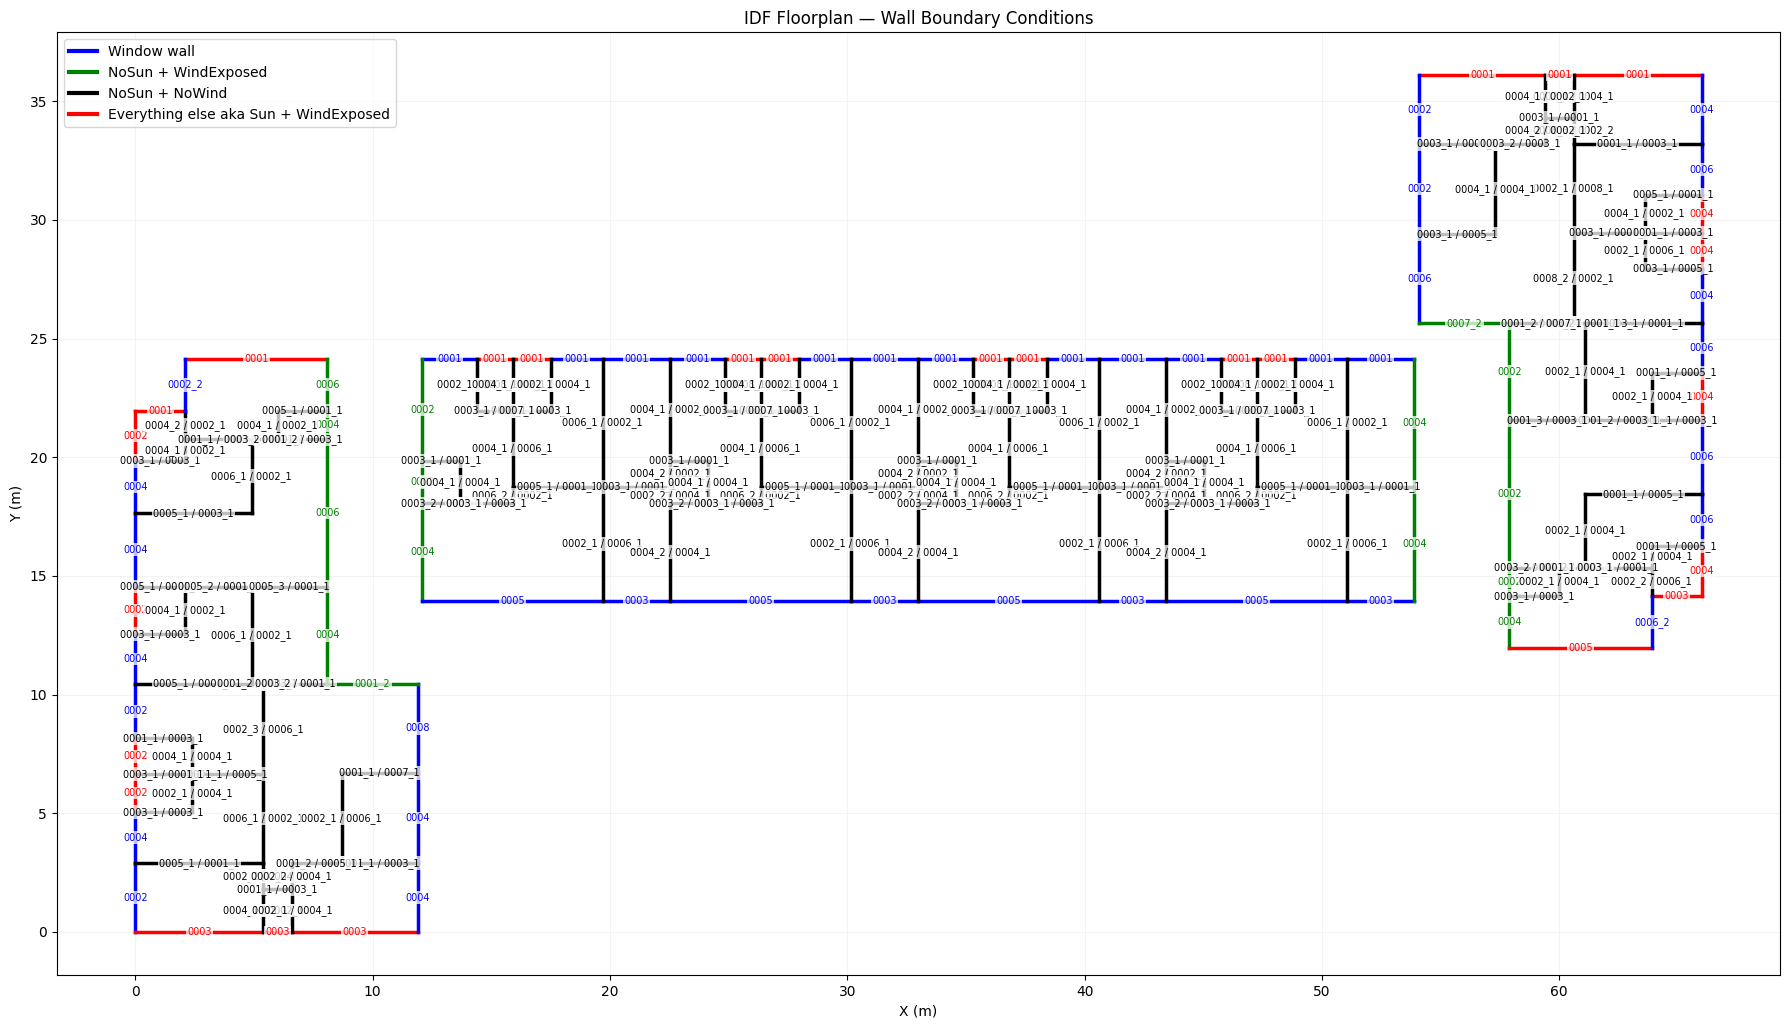

In [5]:
from geomeppy import IDF
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import re

IDD_PATH = r"C:\Users\Heng_\OneDrive\Desktop\Apps\EnergyPlusV9-1-0\Energy+.idd"
IDF_PATH = r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk864\blk_864_base.idf"
IDF.setiddname(IDD_PATH)
idf = IDF(IDF_PATH)

# ============================================================
# Extract wall ID
# ============================================================

def get_wall_id(wall_name):

    # Example:
    # Block 394_bath1 Storey 0 Wall 0002_1
    # -> 0002_1

    match = re.search(r"Wall\s+(\S+)", wall_name)

    if match:
        return match.group(1)

    return wall_name


# ============================================================
# Get wall XY endpoints

def get_wall_xy(wall):

    xy = []
    for x, y, z in wall.coords:
        point = (round(x, 6), round(y, 6))
        if point not in xy:
            xy.append(point)
    if len(xy) < 2:
        return None
    return xy[0], xy[1]

# ============================================================
# Determine walls containing windows

def get_window_walls(idf):
    window_walls = set()
    for window in idf.idfobjects["FENESTRATIONSURFACE:DETAILED"]:
        if window.Surface_Type.lower() == "window":
            window_walls.add(window.Building_Surface_Name)
    return window_walls

# ============================================================
# Wall colour

def get_wall_colour(wall, window_walls):
    # BLUE = wall actually contains window
    if wall.Name in window_walls:
        return "blue"
    sun = wall.Sun_Exposure.strip().lower()
    wind = wall.Wind_Exposure.strip().lower()
    # GREEN = NoSun + WindExposed
    if sun == "nosun" and wind == "windexposed":
        return "green"
    # BLACK = NoSun + NoWind
    if sun == "nosun" and wind == "nowind":
        return "black"
    # RED = everything else
    return "red"

# ============================================================
# Plot IDF floorplan

def plot_idf_floorplan(idf):
    walls = idf.getsurfaces("wall")
    wall_lookup = {wall.Name: wall for wall in walls}

    window_walls = get_window_walls(idf)
    fig, ax = plt.subplots(figsize=(18, 14))
    plotted_pairs = set()

    for wall in walls:
        endpoints = get_wall_xy(wall)
        if endpoints is None:
            continue
        (x1, y1), (x2, y2) = endpoints
        wall_id = get_wall_id(wall.Name)
        label = wall_id

        # ====================================================
        # Shared wall

        if wall.Outside_Boundary_Condition.strip().lower() == "surface":
            other_name = wall.Outside_Boundary_Condition_Object
            if other_name in wall_lookup:
                other_wall = wall_lookup[other_name]
                pair = tuple(sorted([
                    wall.Name,
                    other_wall.Name
                ]))
                # Don't draw same shared wall twice
                if pair in plotted_pairs:
                    continue
                plotted_pairs.add(pair)
                other_id = get_wall_id(other_wall.Name)

                # Show BOTH wall numbers
                label = f"{wall_id} / {other_id}"

        # ====================================================
        # Get wall colour
        colour = get_wall_colour( wall, window_walls)


        # ====================================================
        # Draw wall
        ax.plot([x1, x2], [y1, y2], color=colour,linewidth=2.5)

        # ====================================================
        # Label wall

        xm = (x1 + x2) / 2
        ym = (y1 + y2) / 2

        ax.text(
            xm,
            ym,
            label,
            fontsize=7,
            color=colour,
            ha="center",
            va="center",
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.75,
                pad=1
            )
        )

    # ========================================================
    # Legend

    legend = [

        Line2D(
            [0], [0],
            color="blue",
            lw=3,
            label="Window wall"
        ),

        Line2D(
            [0], [0],
            color="green",
            lw=3,
            label="NoSun + WindExposed"
        ),

        Line2D(
            [0], [0],
            color="black",
            lw=3,
            label="NoSun + NoWind"
        ),

        Line2D(
            [0], [0],
            color="red",
            lw=3,
            label="Everything else aka Sun + WindExposed"
        )
    ]

    ax.legend(handles=legend, loc="best")

    # ========================================================
    # Plot settings

    ax.set_aspect("equal")
    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")
    ax.set_title("IDF Floorplan — Wall Boundary Conditions")
    ax.grid(True, alpha=0.15)
    plt.tight_layout()
    plt.show()

# ============================================================
# Run

plot_idf_floorplan(idf)

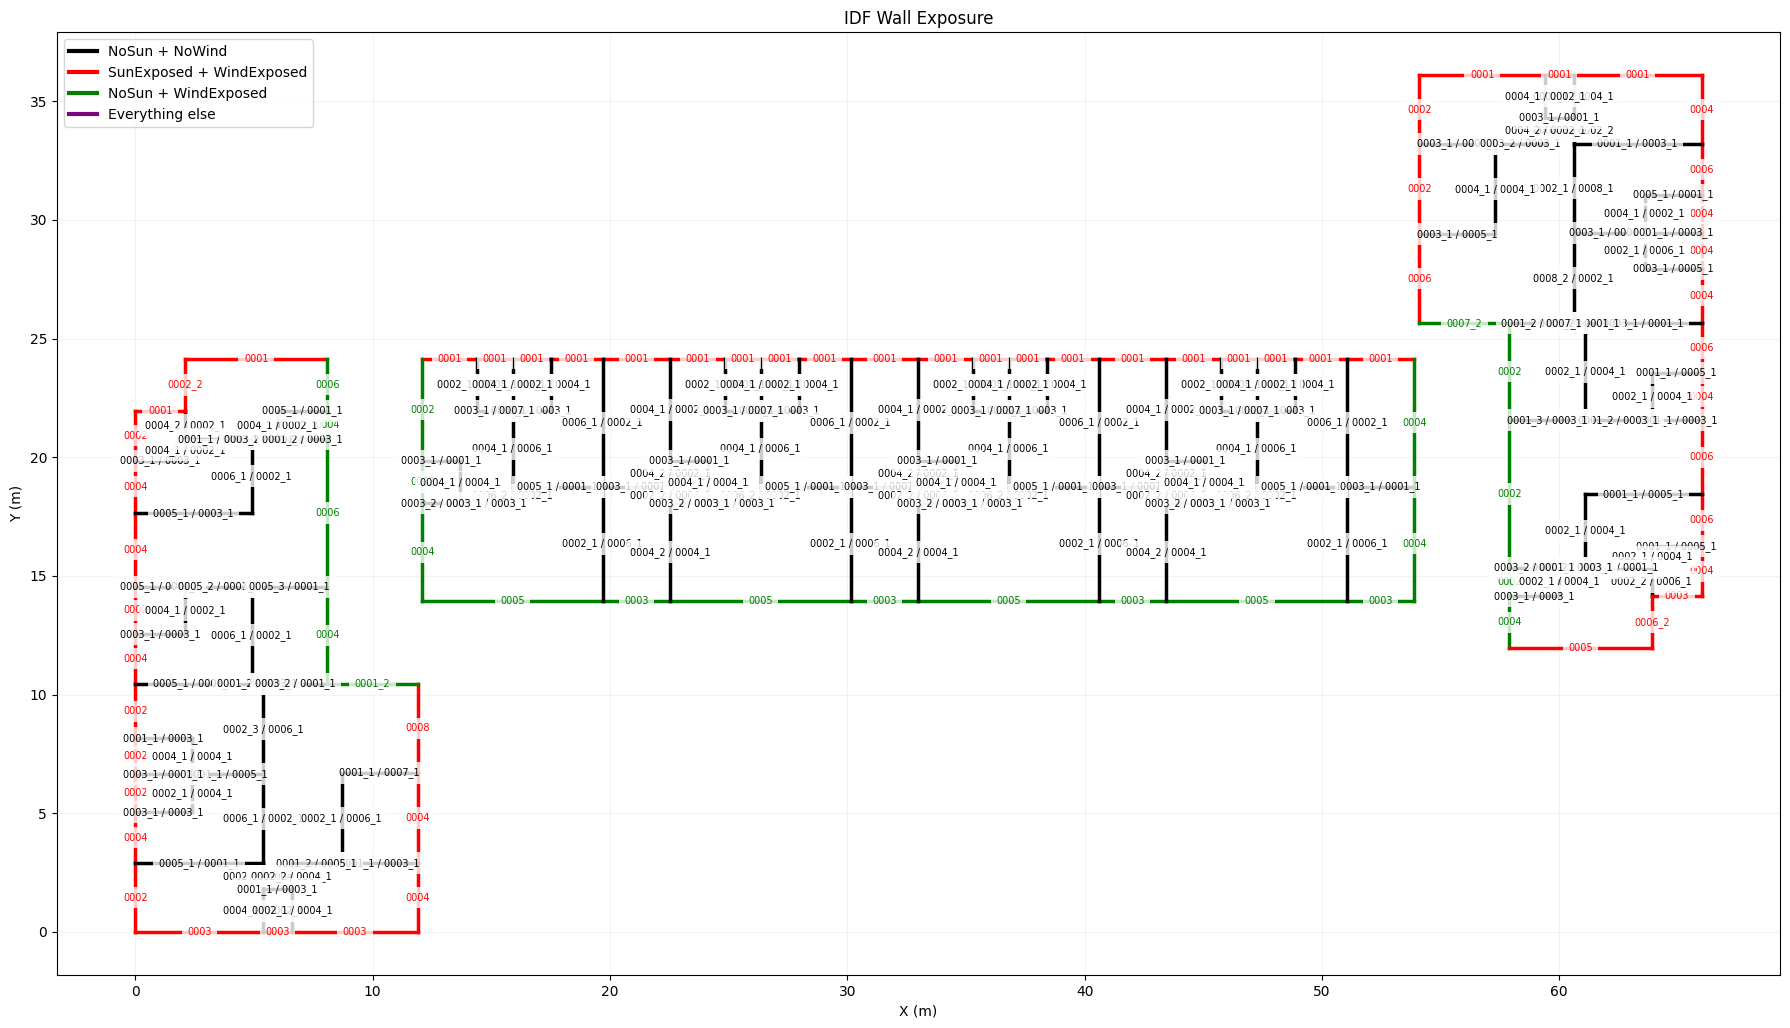

In [ ]:
from geomeppy import IDF
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import re

IDD_PATH = r"C:\Users\Heng_\OneDrive\Desktop\Apps\EnergyPlusV9-1-0\Energy+.idd"
IDF_PATH = r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\blk_864_base.idf"

IDF.setiddname(IDD_PATH)
idf = IDF(IDF_PATH)


def wall_id(name):
    m = re.search(r"Wall\s+(\S+)", name)
    return m.group(1) if m else name


def wall_xy(wall):
    xy = list(dict.fromkeys(
        (round(x, 6), round(y, 6)) for x, y, z in wall.coords
    ))
    return xy[:2] if len(xy) >= 2 else None


def wall_colour(wall):
    condition = (
        wall.Sun_Exposure.strip().lower(),
        wall.Wind_Exposure.strip().lower()
    )

    return {
        ("nosun", "nowind"): "black",
        ("sunexposed", "windexposed"): "red",
        ("nosun", "windexposed"): "green"
    }.get(condition, "purple")


def plot_floorplan(idf):
    walls = idf.getsurfaces("wall")
    lookup = {w.Name: w for w in walls}
    plotted = set()

    fig, ax = plt.subplots(figsize=(18, 14))

    for wall in walls:
        xy = wall_xy(wall)
        if not xy:
            continue

        label = wall_id(wall.Name)

        # Shared wall: show both IDs
        if wall.Outside_Boundary_Condition.lower() == "surface":
            other = lookup.get(wall.Outside_Boundary_Condition_Object)

            if other:
                pair = tuple(sorted((wall.Name, other.Name)))
                if pair in plotted:
                    continue
                plotted.add(pair)

                label += f" / {wall_id(other.Name)}"

        (x1, y1), (x2, y2) = xy
        colour = wall_colour(wall)

        ax.plot([x1, x2], [y1, y2], color=colour, lw=2.5)
        ax.text(
            (x1+x2)/2, (y1+y2)/2, label,
            fontsize=7, color=colour, ha="center", va="center",
            bbox=dict(fc="white", ec="none", alpha=0.8)
        )

    colours = {
        "black": "NoSun + NoWind",
        "red": "SunExposed + WindExposed",
        "green": "NoSun + WindExposed",
        "purple": "Everything else"
    }

    ax.legend([
        Line2D([0], [0], color=c, lw=3) for c in colours
    ], colours.values())

    ax.set_aspect("equal")
    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")
    ax.set_title("IDF Wall Exposure")
    ax.grid(alpha=0.15)
    plt.tight_layout()
    plt.show()


plot_floorplan(idf)